In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/johnsmith88/heart-disease-dataset/heart.csv


In [2]:
df1 = pd.read_csv("/kaggle/input/datasets/johnsmith88/heart-disease-dataset/heart.csv")

In [3]:
df = df1.copy()

# ❤️ Heart Disease Dataset - Feature Description

This dataset contains patient medical information used to predict the presence of heart disease.

| Column | Description | Data Type | Values / Units |
|--------|-------------|-----------|----------------|
| **age** | Age of the patient | Numerical | Years |
| **sex** | Gender of the patient | Categorical | 1 = Male, 0 = Female |
| **cp** | Chest Pain Type | Categorical | 0 = Typical Angina<br>1 = Atypical Angina<br>2 = Non-anginal Pain<br>3 = Asymptomatic |
| **trestbps** | Resting Blood Pressure | Numerical | mm Hg |
| **chol** | Serum Cholesterol | Numerical | mg/dL |
| **fbs** | Fasting Blood Sugar | Categorical | 1 = >120 mg/dL<br>0 = ≤120 mg/dL |
| **restecg** | Resting Electrocardiographic Results | Categorical | 0 = Normal<br>1 = ST-T Wave Abnormality<br>2 = Left Ventricular Hypertrophy |
| **thalach** | Maximum Heart Rate Achieved | Numerical | Beats per Minute (bpm) |
| **exang** | Exercise-Induced Angina | Categorical | 1 = Yes<br>0 = No |
| **oldpeak** | ST Depression induced by exercise relative to rest | Numerical | Float |
| **slope** | Slope of the Peak Exercise ST Segment | Categorical | 0 = Upsloping<br>1 = Flat<br>2 = Downsloping |
| **ca** | Number of Major Vessels Colored by Fluoroscopy | Categorical | Integer (0–4) |
| **thal** | Thalassemia Test Result | Categorical | 1 = Normal<br>2 = Fixed Defect<br>3 = Reversible Defect |
| **target** | Presence of Heart Disease | Target Variable | 1 = Heart Disease Present<br>0 = No Heart Disease |

---

# 📌 Feature Categories

## 🔢 Numerical Feature

- `age`
- `trestbps`
- `chol`
- `thalach`
- `oldpeak`

---

## 🏷️ Categorical Features

- `sex`
- `cp`
- `fbs`
- `restecg`
- `exang`
- `slope`
- `ca`
- `thal`

---

## 🎯 Target Variable

| Value | Meaning |
|-------|---------|
| **0** | No Heart Disease |
| **1** | Heart Disease Present |

---

# 📖 Medical Terminology

- **Angina:** Chest pain caused by reduced blood flow to the heart.
- **ECG (Electrocardiogram):** A test that records the electrical activity of the heart.
- **ST Depression:** A change observed in an ECG that may indicate reduced blood flow to the heart.
- **Thalassemia:** A blood disorder. In this dataset, the **thal** feature represents the result of a thallium stress test used to evaluate blood flow to the heart.
- **Fluoroscopy:** An imaging technique used to visualize the major blood vessels supplying the heart.

---

# 📊 Dataset Summary

- **Problem Type:** Binary Classification
- **Domain:** Healthcare / Medical Diagnosis
- **Input Features:** 13
- **Target Feature:** `target`
- **Goal:** Predict whether a patient is likely to have heart disease based on clinical measurements and diagnostic test results.

In [4]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [5]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(723)

In [7]:
df.shape

(1025, 14)

In [8]:
df[df.duplicated()]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
15,34,0,1,118,210,0,1,192,0,0.7,2,0,2,1
31,50,0,1,120,244,0,1,162,0,1.1,2,0,2,1
43,46,1,0,120,249,0,0,144,0,0.8,2,0,3,0
55,55,1,0,140,217,0,1,111,1,5.6,0,0,3,0
61,66,0,2,146,278,0,0,152,0,0.0,1,1,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


In [9]:
df.drop_duplicates(inplace = True)

In [10]:
df.shape

(302, 14)

In [11]:
import matplotlib.pyplot as plt

(array([ 1., 10., 33., 38., 37., 60., 63., 43., 14.,  3.]),
 array([29. , 33.8, 38.6, 43.4, 48.2, 53. , 57.8, 62.6, 67.4, 72.2, 77. ]),
 <BarContainer object of 10 artists>)

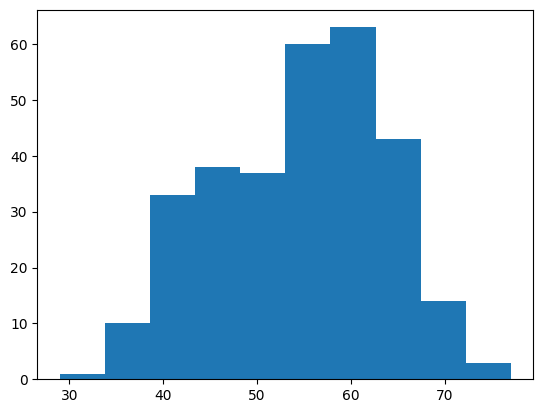

In [12]:
plt.hist(df["age"])

([<matplotlib.patches.Wedge at 0x7ad6a2ac5fd0>,
 [Text(-0.14830457177720838, 1.0899567670279309, '0'),
  Text(0.14830479699722773, -1.089956736383427, '1')])

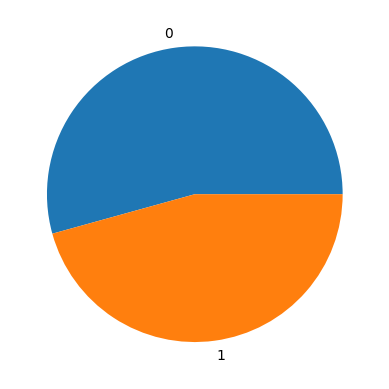

In [13]:
plt.pie(df["target"].value_counts(),labels = ["0","1"])

# From the above pie chart we can say the target class is kind of balanced

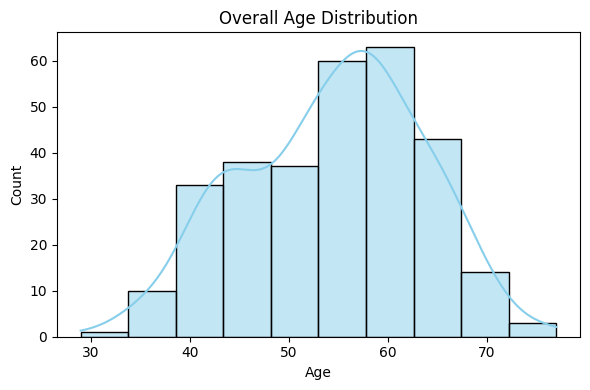

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df['age_group'] = pd.cut(df['age'], bins=[25, 39, 49, 59, 69, 80], labels=['<40', '40s', '50s', '60s', '70s'])

plt.figure(figsize=(6, 4))

sns.histplot(data=df, x='age', bins=10, color='skyblue', kde=True)
plt.title('Overall Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')

plt.tight_layout()
plt.show()


<Axes: xlabel='age_group', ylabel='count'>

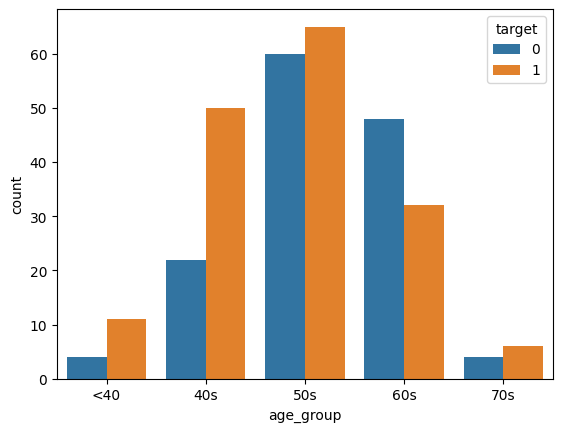

In [15]:
sns.countplot(data=df, x='age_group', hue='target')

<Axes: xlabel='sex'>

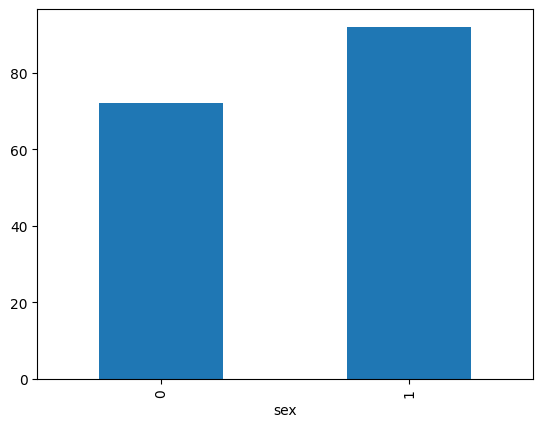

In [16]:
df.groupby("sex")["target"].sum().plot(kind = "bar")

In [17]:
rates = df.groupby('sex')['target'].mean()

female_rate = rates[0]
male_rate = rates[1]

percentage_diff = abs(male_rate - female_rate) * 100

print(f"Female Heart Disease Rate: {female_rate * 100:.1f}%")
print(f"Male Heart Disease Rate: {male_rate * 100:.1f}%")
print(f"The difference is {percentage_diff:.1f} percentage points.")


Female Heart Disease Rate: 75.0%
Male Heart Disease Rate: 44.7%
The difference is 30.3 percentage points.


# we can say that male are more prone to heart disease than women

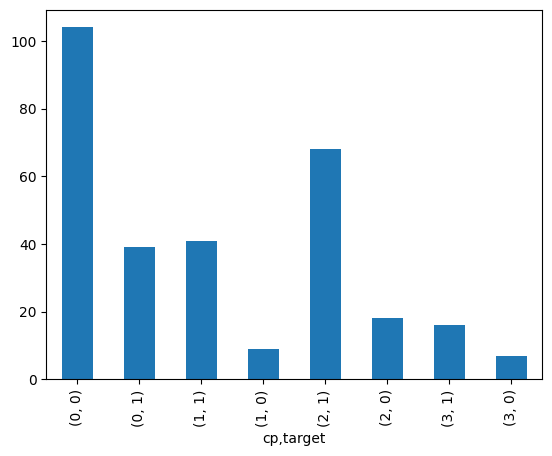

In [18]:
df.groupby("cp")["target"].value_counts().plot(kind = "bar")
plt.show()

246.5


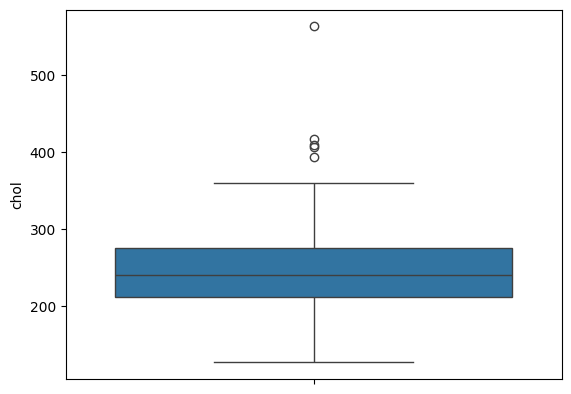

In [19]:
sns.boxplot(df['chol'])
print(df['chol'].mean())

<Axes: xlabel='chol_range', ylabel='count'>

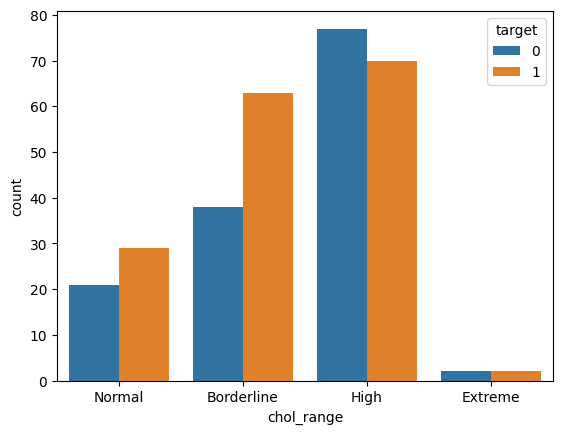

In [20]:
import seaborn as sns

# 1. Create 4 clean cholesterol ranges
df['chol_range'] = pd.cut(df['chol'], bins=[0, 200, 240, 400, 600], labels=['Normal', 'Borderline', 'High', 'Extreme'])

# 2. Plot the ranges against the target
sns.countplot(data=df, x='chol_range', hue='target')


In [21]:
from scipy import stats

# Separate cholesterol values by target
healthy = df[df['target'] == 0]['chol']
sick = df[df['target'] == 1]['chol']

# Run the T-test
t_stat, p_val = stats.ttest_ind(healthy, sick)
print(f"P-value: {p_val:.4f}")
if p_val<0.05:
    print("there is relation between cholestrol and target")
else:
    print("no relation between cholestrol and target")


P-value: 0.1580
no relation between cholestrol and target


In [22]:
import pandas as pd
from scipy import stats

# 1. Create a binary flag: 1 if patient has Type 2 chest pain, 0 otherwise
df['has_cp2'] = (df['cp'] == 2).astype(int)

# 2. Build a 2x2 contingency table (Cross-tabulation)
contingency_table = pd.crosstab(df['has_cp2'], df['target'])

# 3. Run the Chi-Square test
chi2, p_val, dof, expected = stats.chi2_contingency(contingency_table)
print(f"Chi-Square P-value: {p_val:.6f}")
print("there is significant realtion between cp 2 and target")


Chi-Square P-value: 0.000000
there is significant realtion between cp 2 and target


In [23]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,age_group,chol_range,has_cp2
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0,50s,Borderline,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0,50s,Borderline,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0,70s,Normal,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0,60s,Borderline,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0,60s,High,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
723,68,0,2,120,211,0,0,115,0,1.5,1,0,2,1,60s,Borderline,1
733,44,0,2,108,141,0,1,175,0,0.6,1,0,2,1,40s,Normal,1
739,52,1,0,128,255,0,1,161,1,0.0,2,1,3,0,50s,High,0
843,59,1,3,160,273,0,0,125,0,0.0,2,0,2,0,50s,High,0


ca  target
0   1         130
    0          45
1   0          44
    1          21
2   0          31
    1           7
3   0          17
    1           3
4   1           3
    0           1
Name: count, dtype: int64


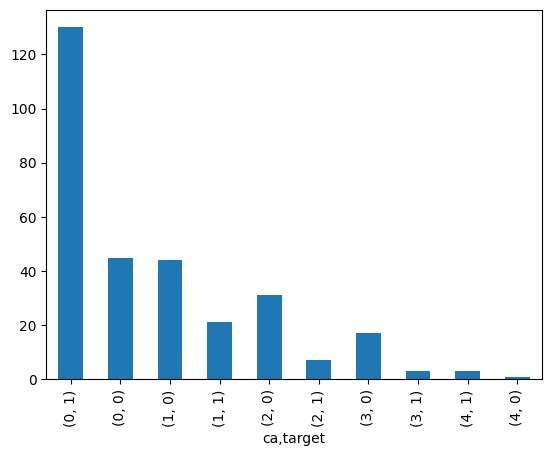

In [24]:
df.groupby("ca")["target"].value_counts().plot(kind = "bar")
print(df.groupby("ca")["target"].value_counts())

In [25]:
ca_target = pd.crosstab(df["ca"],df["target"])

In [26]:
from scipy.stats import chi2_contingency
chi2_stat, p_val, dof, expected = chi2_contingency(ca_target)

print(f"Chi-Square Statistic: {chi2_stat:.4f}")
print(f"P-value: {p_val:.4f}")
print(f"Degrees of Freedom: {dof}")
print("Expected Frequencies:\n", expected)
print("There is relationship between the ca and target in which is there are less number of vessels coloured in fluroscopy")

Chi-Square Statistic: 73.6898
P-value: 0.0000
Degrees of Freedom: 4
Expected Frequencies:
 [[79.96688742 95.03311258]
 [29.70198675 35.29801325]
 [17.36423841 20.63576159]
 [ 9.13907285 10.86092715]
 [ 1.82781457  2.17218543]]
There is relationship between the ca and target in which is there are less number of vessels coloured in fluroscopy


In [27]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,age_group,chol_range,has_cp2
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0,50s,Borderline,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0,50s,Borderline,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0,70s,Normal,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0,60s,Borderline,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0,60s,High,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
723,68,0,2,120,211,0,0,115,0,1.5,1,0,2,1,60s,Borderline,1
733,44,0,2,108,141,0,1,175,0,0.6,1,0,2,1,40s,Normal,1
739,52,1,0,128,255,0,1,161,1,0.0,2,1,3,0,50s,High,0
843,59,1,3,160,273,0,0,125,0,0.0,2,0,2,0,50s,High,0


In [28]:
df.groupby("fbs")["target"].value_counts()

fbs  target
0    1         141
     0         116
1    1          23
     0          22
Name: count, dtype: int64

In [29]:
fbs_target = pd.crosstab(df["fbs"],df["target"])
chi2_stat, p_val, dof, expected = chi2_contingency(fbs_target)

print(f"Chi-Square Statistic: {chi2_stat:.4f}")
print(f"P-value: {p_val:.4f}")
print(f"Degrees of Freedom: {dof}")
print("Expected Frequencies:\n", expected)

Chi-Square Statistic: 0.0924
P-value: 0.7611
Degrees of Freedom: 1
Expected Frequencies:
 [[117.43708609 139.56291391]
 [ 20.56291391  24.43708609]]


In [30]:
fbs_target

target,0,1
fbs,,
0,116,141
1,22,23


# No significant relation between the fbs and target

In [31]:
fbs_chol = pd.crosstab(df["fbs"],df["chol_range"])

In [32]:
chi2_stat, p_val, dof, expected = chi2_contingency(fbs_chol)

print(f"Chi-Square Statistic: {chi2_stat:.4f}")
print(f"P-value: {p_val:.4f}")
print(f"Degrees of Freedom: {dof}")
print("Expected Frequencies:\n", expected)


Chi-Square Statistic: 0.5042
P-value: 0.9180
Degrees of Freedom: 3
Expected Frequencies:
 [[ 42.54966887  85.95033113 125.09602649   3.40397351]
 [  7.45033113  15.04966887  21.90397351   0.59602649]]


# With the help of chi square test we can say that there is no relation in the fbs and choelstrol


In [33]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,age_group,chol_range,has_cp2
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0,50s,Borderline,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0,50s,Borderline,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0,70s,Normal,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0,60s,Borderline,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0,60s,High,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
723,68,0,2,120,211,0,0,115,0,1.5,1,0,2,1,60s,Borderline,1
733,44,0,2,108,141,0,1,175,0,0.6,1,0,2,1,40s,Normal,1
739,52,1,0,128,255,0,1,161,1,0.0,2,1,3,0,50s,High,0
843,59,1,3,160,273,0,0,125,0,0.0,2,0,2,0,50s,High,0


In [34]:
df.groupby("restecg")["target"].value_counts()

restecg  target
0        0         79
         1         68
1        1         95
         0         56
2        0          3
         1          1
Name: count, dtype: int64

In [35]:
restecg_target = pd.crosstab(df["restecg"],df["target"])

In [36]:
chi2_stat, p_val, dof, expected = chi2_contingency(restecg_target)

print(f"Chi-Square Statistic: {chi2_stat:.4f}")
print(f"P-value: {p_val:.4f}")
print(f"Degrees of Freedom: {dof}")
print("Expected Frequencies:\n", expected)

Chi-Square Statistic: 9.7297
P-value: 0.0077
Degrees of Freedom: 2
Expected Frequencies:
 [[67.17218543 79.82781457]
 [69.         82.        ]
 [ 1.82781457  2.17218543]]


In [37]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

# Contingency table
contingency = pd.crosstab(df['restecg'], df['target'])

# Chi-square test
chi2, p, dof, expected = chi2_contingency(contingency)

# Sample size
n = contingency.sum().sum()

# Number of rows and columns
r, c = contingency.shape

# Cramer's V
cramers_v = np.sqrt(chi2 / (n * (min(r - 1, c - 1))))

print(f"Chi-Square Statistic : {chi2:.4f}")
print(f"P-value              : {p:.4f}")
print(f"Degrees of Freedom   : {dof}")
print(f"Cramer's V           : {cramers_v:.4f}")

Chi-Square Statistic : 9.7297
P-value              : 0.0077
Degrees of Freedom   : 2
Cramer's V           : 0.1795


# From chi_square test we found there is association between restech and target and with cramer v test we found the strength of the association which is weak

<Axes: ylabel='thalach'>

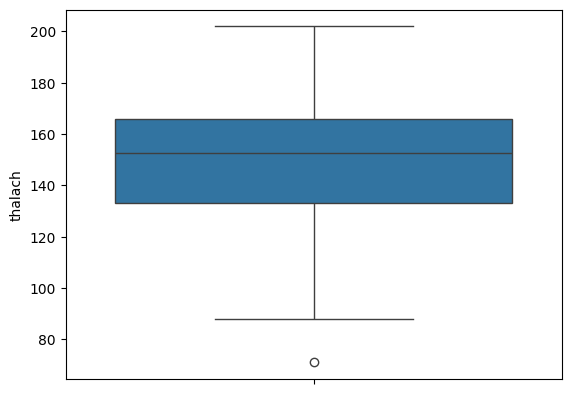

In [38]:
sns.boxplot(df["thalach"])

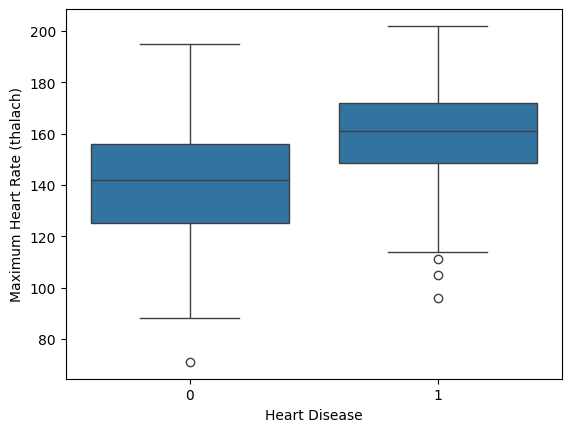

In [39]:
sns.boxplot(x='target', y='thalach', data=df)

plt.xlabel("Heart Disease")
plt.ylabel("Maximum Heart Rate (thalach)")
plt.show()

In [40]:
df["thalach"].describe()

count    302.000000
mean     149.569536
std       22.903527
min       71.000000
25%      133.250000
50%      152.500000
75%      166.000000
max      202.000000
Name: thalach, dtype: float64

In [41]:
from scipy.stats import pointbiserialr

r, p = pointbiserialr(df['target'], df['thalach'])

print("Correlation:", r)
print("P-value:", p)


Correlation: 0.4199550436638701
P-value: 2.476146047923492e-14


# There is a moderate positive relation between target and thalach which means when thalach is high there is chance for target = 1 